<a href="https://colab.research.google.com/github/EJamdar05/cs276-project/blob/main/CS276_Project_Ukraine_Graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

df = pd.read_csv('data/clean_data/output.csv')
df.head()

,tweet_id,lang,country,verified,sentiment_neutral,entail_prob,contra_prob,stance,region
0,1540451336876986373,cs,Slovakia,True,0.5044,0.30,0.70,unsure,Europe
1,1516696238212661253,ro,Italy,False,0.9146,0.18,0.82,unsure,Europe
2,1587766197298548738,te,India,True,0.5799,0.31,0.69,unsure,Asia
3,1586193152175529984,te,India,True,0.0000,0.03,0.97,unsure,Asia
4,1580452730212331520,te,India,True,0.0000,0.33,0.67,pro-Ukraine,Asia


In [3]:
B = nx.Graph()

stances = df["stance"].unique()
regions = df["region"].unique()

print(stances)
print(regions)

['unsure' 'pro-Ukraine' 'pro-Russia']
['Europe' 'Asia' 'North America' 'Africa' 'Middle East' 'Oceania'
 'South America']


In [4]:
B = nx.MultiGraph()
B.add_nodes_from(stances, bipartite='stance')
B.add_nodes_from(regions, bipartite='region')

for index, row in df.iterrows():
    stance = row["stance"]
    region = row["region"]
    tweet_id = row["tweet_id"]
    entail_prob = row["entail_prob"]
    contra_prob = row["contra_prob"]
    weight = entail_prob 
    
    
    B.add_edge(stance, region, weight=weight, tweet_id=tweet_id, 
               entail_prob=entail_prob, contra_prob=contra_prob)

print(f"Nodes: {B.number_of_nodes()}")
print(f"Edges: {B.number_of_edges()}")




Nodes: 10
Edges: 646573


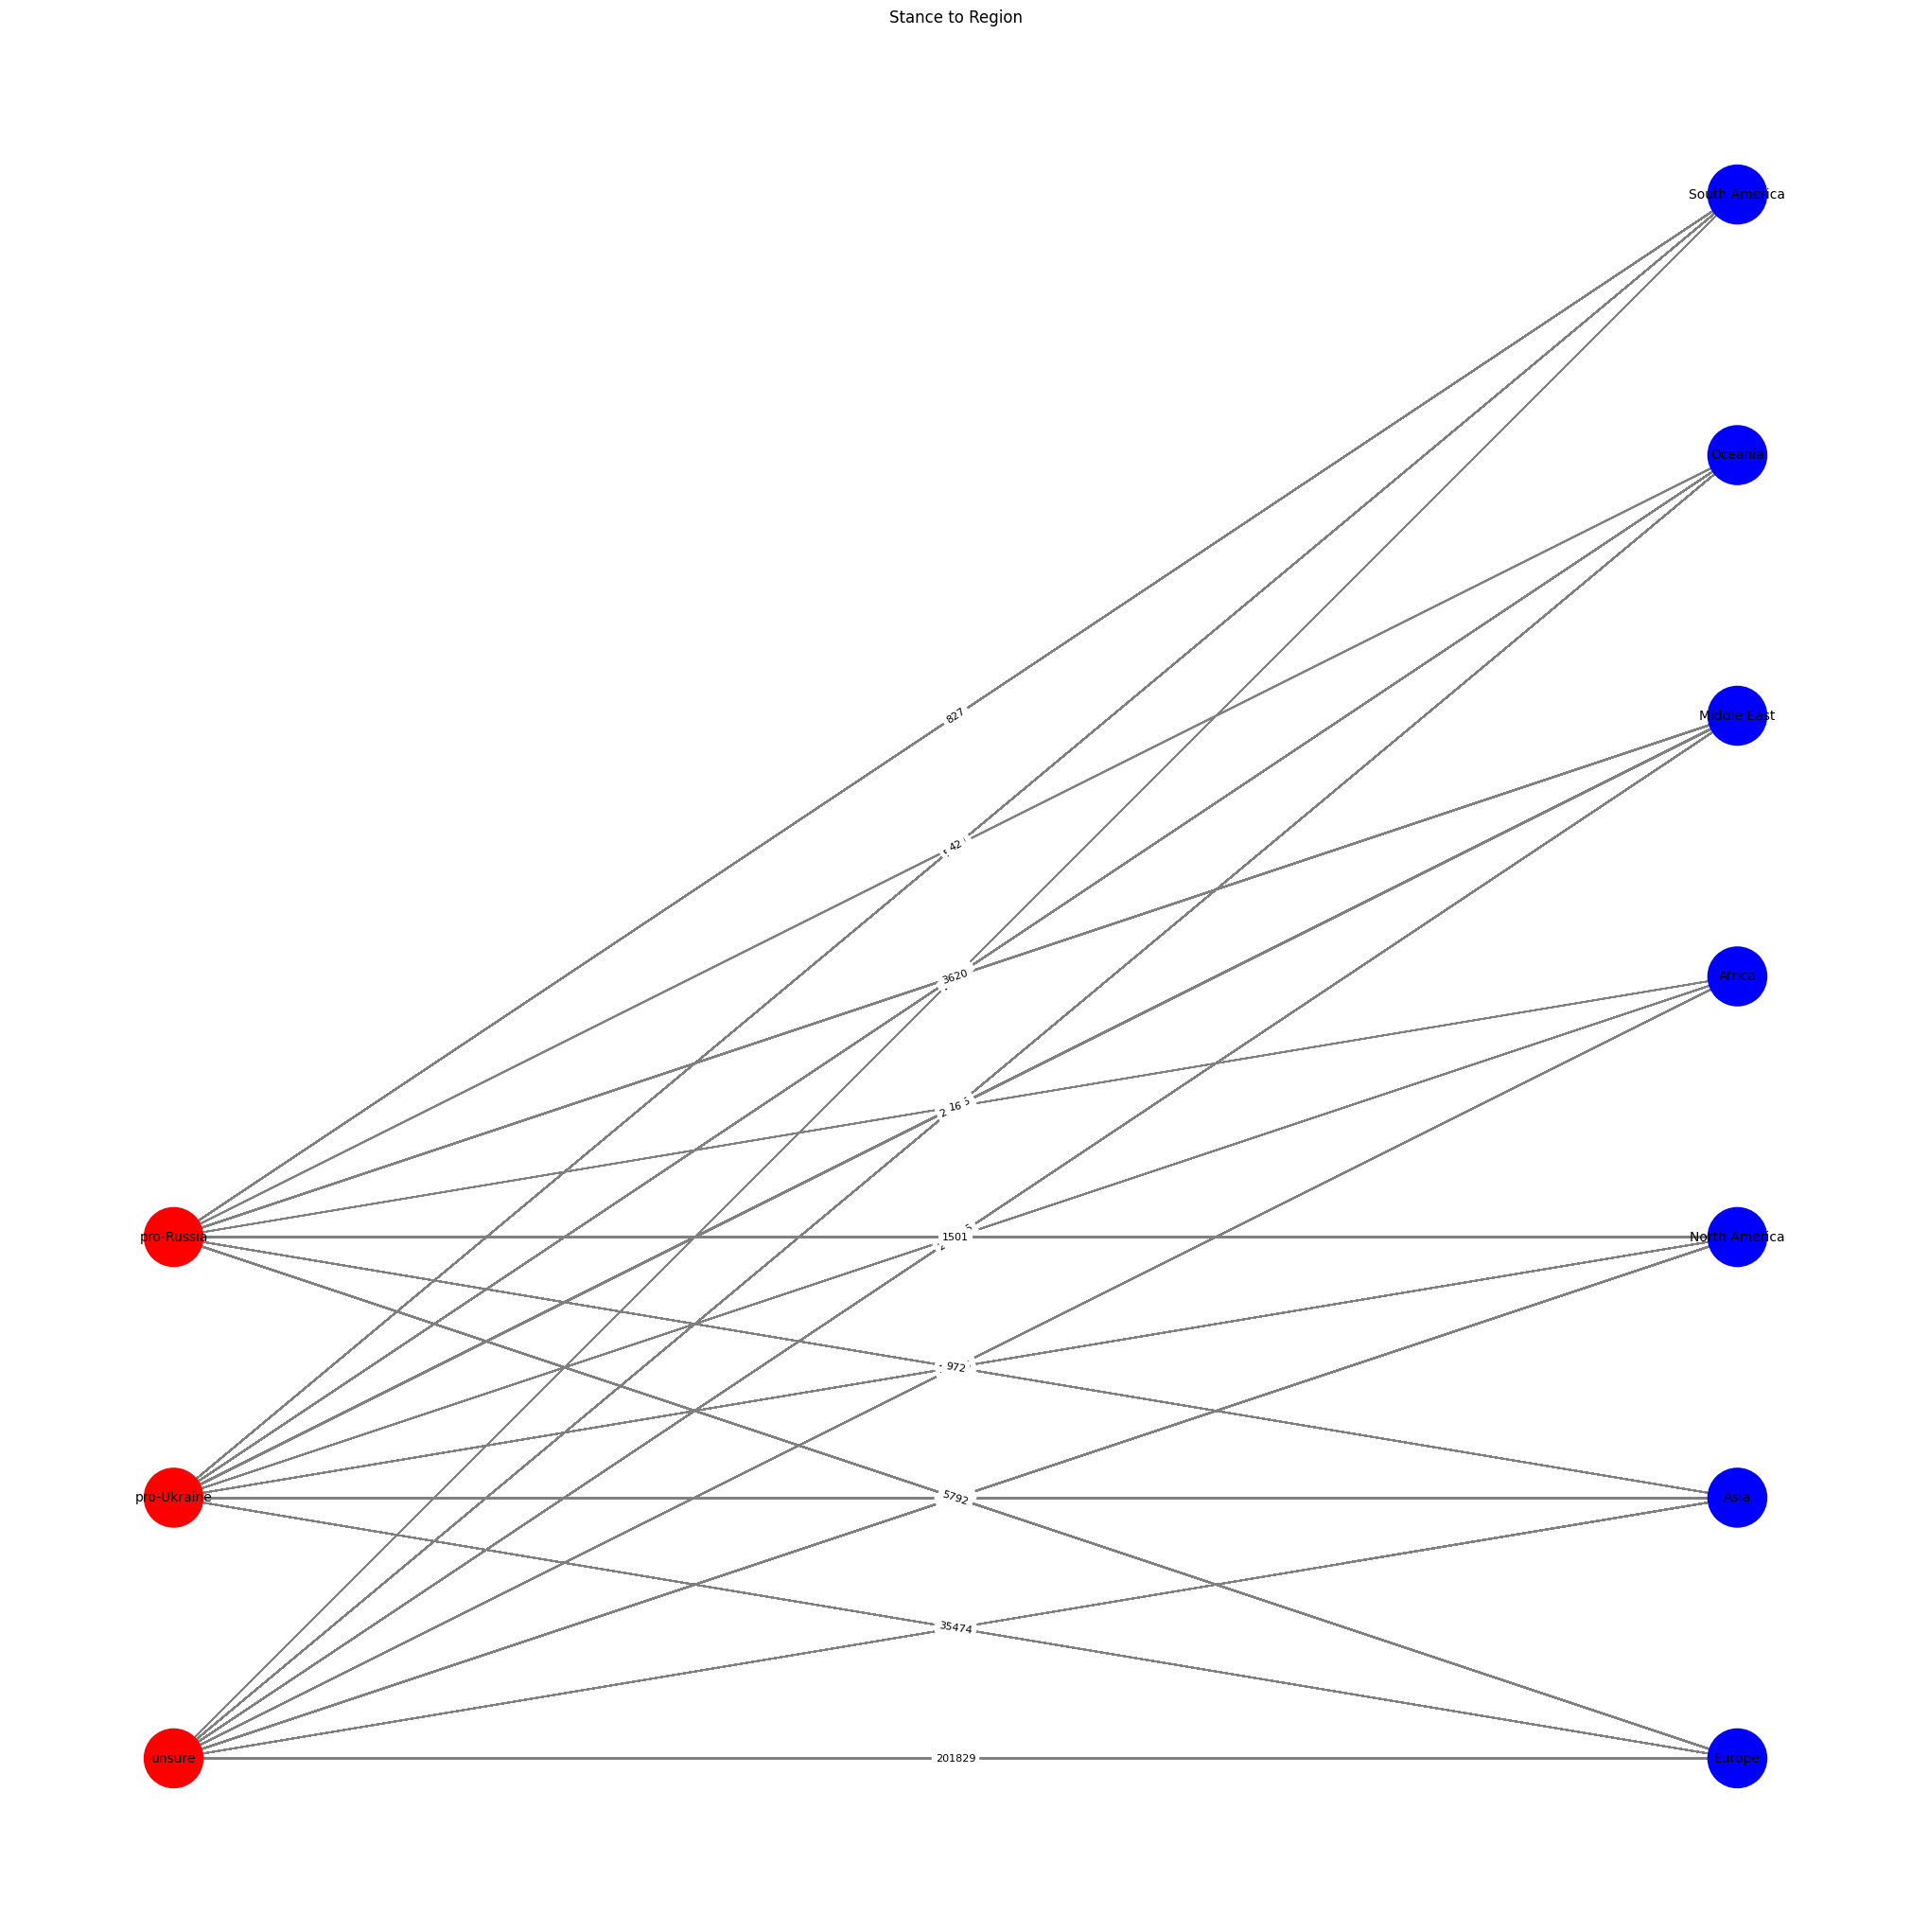

In [5]:
import matplotlib.pyplot as plt
import networkx as nx

pos = {}

# left side
for i, node in enumerate(stances):
    pos[node] = (0, i)
# right side
for i, node in enumerate(regions):
    pos[node] = (1, i)


plt.figure(figsize=(20, 20))

node_colors = ['red' if node in stances else 'blue' for node in B.nodes()]


nx.draw(B, pos=pos, node_color=node_colors, with_labels=True, 
        node_size=2000, font_size=10, edge_color='gray')

# condense the edges into counts (less edges visually)
edge_counts = {}
for u, v, key in B.edges.keys():
    if (u,v) in edge_counts:
        edge_counts[(u, v)] += 1
    elif (v,u) in edge_counts:
        edge_counts[(v, u)] += 1
    else:
        edge_counts[(u, v)] = 1

nx.draw_networkx_edge_labels(B, pos=pos, edge_labels=edge_counts, font_size=8)

plt.title("Stance to Region")
plt.axis('off')
plt.show()
nx.write_edgelist(B, "data/clean_data/region_stances_per_region.edgelist")


In [321]:
import community as community_louvain

partition = community_louvain.best_partition(B, weight='weight')
num_communities = len(set(partition.values()))
print(f"Detected {num_communities} communities")


communities_dict = {}
for node, id in partition.items():
    if id not in communities_dict:
        communities_dict[id] = []
    communities_dict[id].append(node)

for community_id, nodes in communities_dict.items():
    stance_count = sum(1 for node in nodes if B.nodes[node]['bipartite'] == 'stance')
    region_count = sum(1 for node in nodes if B.nodes[node]['bipartite'] == 'region')
    print(f"Community {community_id}: {len(nodes)} nodes ({stance_count} stances, {region_count} regions)")
    print("Stances:", [node for node in nodes if B.nodes[node]['bipartite'] == 'stance'])
    print("Regions:", [node for node in nodes if B.nodes[node]['bipartite'] == 'region'])



Detected 2 communities
Community 1: 3 nodes (1 stances, 2 regions)
Stances: ['unsure']
Regions: ['Europe', 'Middle East']
Community 0: 7 nodes (2 stances, 5 regions)
Stances: ['pro-Ukraine', 'pro-Russia']
Regions: ['Asia', 'North America', 'Africa', 'Oceania', 'South America']


In [454]:
from node2vec import Node2Vec
import pandas as pd

node2vec = Node2Vec(B, dimensions=128, walk_length=80, num_walks=300, p=0.5, q=4, workers=4, weight_key='weight')
model = node2vec.fit(window=15, min_count=1)


node_embeddings = {node: model.wv[node] for node in B.nodes()}
embedding_df = pd.DataFrame.from_dict(node_embeddings, orient='index')
# print(embedding_df.head())

from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

region_embeddings = embedding_df.loc[regions]
stance_embeddings = embedding_df.loc[stances]
similarity_matrix = cosine_similarity(region_embeddings, stance_embeddings)

similarity_df = pd.DataFrame(similarity_matrix, index=region_embeddings.index, columns=stances)

region_to_stance = {}

for region in similarity_df.index:
    assigned_stance = similarity_df.loc[region].idxmax()
    region_to_stance[region] = assigned_stance

for region, stance in region_to_stance.items():
    print(f"{region}: {stance}")


Generating walks (CPU: 4): 100%|██████████| 75/75 [00:00<00:00, 989.24it/s]


Europe: pro-Ukraine
Asia: unsure
North America: pro-Russia
Africa: pro-Ukraine
Middle East: pro-Ukraine
Oceania: pro-Russia
South America: pro-Russia
